In [49]:
from astropy.io import ascii
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from scipy.optimize import curve_fit
from astropy.coordinates import SkyCoord

### Problem 3

In [55]:
M81_coord = SkyCoord(148.89,69.07, unit='deg')
M82_coord = SkyCoord(148.97,69.68, unit='deg')
angsep = M82_coord.separation(M81_coord)
print('Angular Seperation: {:.3f}'.format(angsep))
print('Angular Seperation: {:.3f}'.format(angsep.to('arcmin')))

Angular Seperation: 0.611 deg
Angular Seperation: 36.639 arcmin


### Problem 6

In [33]:
filename='stanphot.dat'
if not os.path.isfile(filename):
    stan_phot= ascii.read('https://burro.case.edu/Academics/Astr306/HW/HW1/'+filename)
    ascii.write(stan_phot, filename, overwrite=True)
else:
    stan_phot=ascii.read(filename)

In [34]:
star = stan_phot['Star'] 
v_mag = stan_phot['V']
B_V_color = stan_phot['B-V'] 
airmass = stan_phot['Airmass'] 
b_inst = stan_phot['Binst'] 
v_inst = stan_phot['Vinst'] 

In [35]:
stan_phot['b_true'] = v_mag + B_V_color 

In [36]:
stan_phot['y_B'] = b_inst - stan_phot['b_true']
stan_phot['y_V'] = v_inst - v_mag

In [37]:
def photometric_model(X, K, ZP):
    return K * X + ZP

In [38]:
popt_B, pcov_B = curve_fit(
    photometric_model,
    airmass,
    stan_phot['y_B']
)

K_B, ZP_B = popt_B
dK_B, dZP_B = np.sqrt(np.diag(pcov_B))

popt_V, pcov_V = curve_fit(
    photometric_model,
    airmass,
    stan_phot['y_V']
)

K_V, ZP_V = popt_V
dK_V, dZP_V = np.sqrt(np.diag(pcov_V))

In [39]:
print(f"B band: K = {K_B:.3f} ± {dK_B:.3f}, ZP = {ZP_B:.3f} ± {dZP_B:.3f}")
print(f"V band: K = {K_V:.3f} ± {dK_V:.3f}, ZP = {ZP_V:.3f} ± {dZP_V:.3f}")

B band: K = 0.252 ± 0.033, ZP = 3.559 ± 0.058
V band: K = 0.149 ± 0.032, ZP = 3.401 ± 0.056


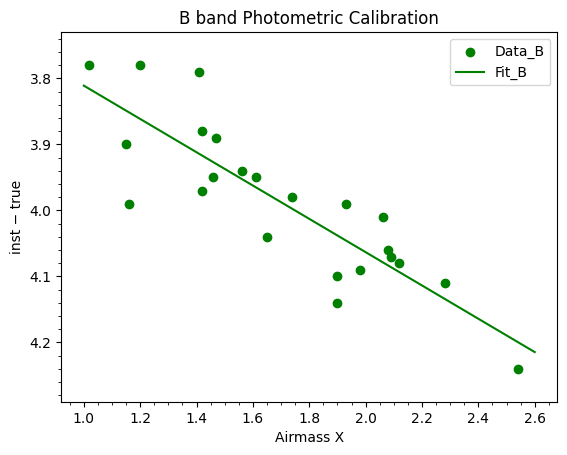

In [47]:
plt.scatter(airmass, stan_phot['y_B'], label="Data_B", color = 'green')
xfit = np.linspace(1,2.6, 100)
plt.plot(xfit, photometric_model(xfit, K_B, ZP_B), label="Fit_B", color = 'green')
plt.xlabel("Airmass X")
plt.ylabel(f"inst − true")
plt.minorticks_on()
plt.ylim(stan_phot['y_B'].max()+.05, stan_phot['y_B'].min()-.05)
plt.title(f"B band Photometric Calibration")
plt.legend()

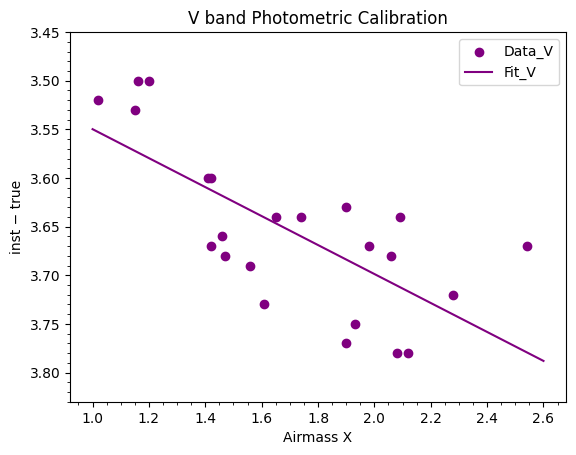

In [48]:
xfit = np.linspace(1,2.6, 100)
plt.scatter(airmass, stan_phot['y_V'], label="Data_V", color = 'purple')
plt.plot(xfit, photometric_model(xfit, K_V, ZP_V), label="Fit_V", color = 'purple')
plt.xlabel("Airmass X")
plt.ylabel(f"inst − true")
plt.minorticks_on()
plt.ylim(stan_phot['y_V'].max()+.05, stan_phot['y_V'].min()-.05)
plt.title(f"V band Photometric Calibration")
plt.legend()